In [1]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/jebbonanno/opt/anaconda3/lib/python3.9/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): symbol not found in flat namespace '_R_BaseEnv'")
Trying to import in ABI mode.


In [20]:
import pandas as pd
import numpy as np


import matplotlib as plt
import plotly.express as px


#R transfer
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
pandas2ri.activate()

DeprecationWarning: 
The activate and deactivate are deprecated. To set a conversion
context check the docstring for rpy2.robjects.conversion.Converter.context.


In [3]:
%%R
library(hellodatascience)
library(tidyverse)

data("atus_college")
head(atus_college)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
# A tibble: 6 × 13
  employment   age enrollment weekly_earnings household_size time_alone
  <fct>      <dbl> <fct>                <dbl>          <dbl>      <dbl>
1 Part Time     19 Part Time             400               6        326
2 Full Time     23 Full Time            1477.              2        150
3 Part Time     22 Full Time             561.              2        357
4 Part Time     21 Full Time             100               4         22
5 <NA>          26 Full T

In [4]:
atus_python = robjects.r['atus_college']
# convert to pandas
atus_df = pandas2ri.rpy2py(atus_python)

### Head

In [12]:
%%R 

head(atus_college)
glimpse(atus_college)

Rows: 312
Columns: 13
$ employment        <fct> Part Time, Full Time, Part Time, Part Time, NA, Part…
$ age               <dbl> 19, 23, 22, 21, 26, 25, 27, 36, 30, 20, 18, 20, 25, …
$ enrollment        <fct> Part Time, Full Time, Full Time, Full Time, Full Tim…
$ weekly_earnings   <dbl> 400.00, 1476.92, 561.25, 100.00, NA, 300.00, 1076.92…
$ household_size    <dbl> 6, 2, 2, 4, 2, 3, 3, 1, 3, 2, 4, 4, 2, 2, 4, 5, 4, 2…
$ time_alone        <dbl> 326, 150, 357, 22, 0, 455, 90, 340, 326, 120, 285, 5…
$ sleep_time        <dbl> 680, 180, 470, 660, 875, 765, 630, 300, 445, 630, 66…
$ work_time         <dbl> 315, 0, 0, 0, 0, 0, 0, 645, 555, 0, 0, 0, 520, 615, …
$ degree_class_time <dbl> 0, 0, 238, 0, 0, 0, 0, 0, 0, 0, 0, 228, 0, 0, 0, 0, …
$ shopping_time     <dbl> 14, 0, 0, 0, 0, 0, 0, 5, 20, 345, 0, 0, 0, 0, 0, 0, …
$ lunch_break_time  <dbl> 66, 60, 20, 115, 35, 50, 25, 30, 75, 60, 15, 15, 60,…
$ sports_time       <dbl> 0, 60, 0, 30, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15, 0, 0, 0…
$ religious_time  

In [6]:
atus_df.head()

,employment,age,enrollment,weekly_earnings,household_size,time_alone,sleep_time,work_time,degree_class_time,shopping_time,lunch_break_time,sports_time,religious_time
1,2,19.0,2,400.00,6.0,326.0,680.0,315.0,0.0,14.0,66.0,0.0,0.0
2,1,23.0,1,1476.92,2.0,150.0,180.0,0.0,0.0,0.0,60.0,60.0,0.0
3,2,22.0,1,561.25,2.0,357.0,470.0,0.0,238.0,0.0,20.0,0.0,0.0
4,2,21.0,1,100.00,4.0,22.0,660.0,0.0,0.0,0.0,115.0,30.0,0.0
5,-2147483648,26.0,1,NaN,2.0,0.0,875.0,0.0,0.0,0.0,35.0,0.0,0.0


In [ ]:
### Basic Bar Plot

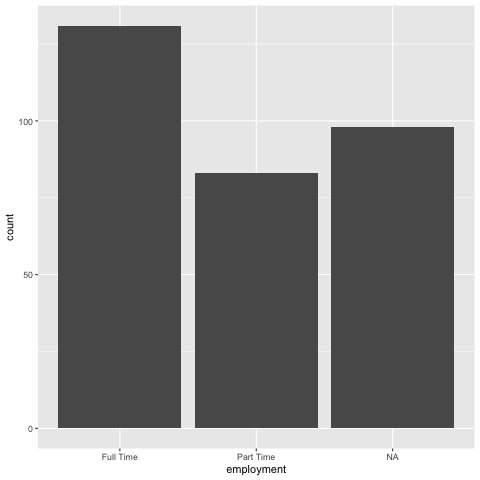

In [7]:
%%R
ggplot(data = atus_college, aes(x=employment)) + geom_bar()

<AxesSubplot:>

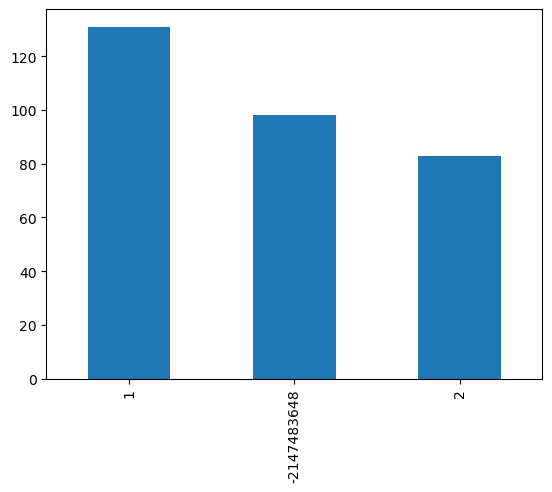

In [18]:
atus_df['employment'].value_counts().plot(kind='bar')

In [24]:
atus_df['employment'].value_counts()

 1             131
-2147483648     98
 2              83
Name: employment, dtype: int64

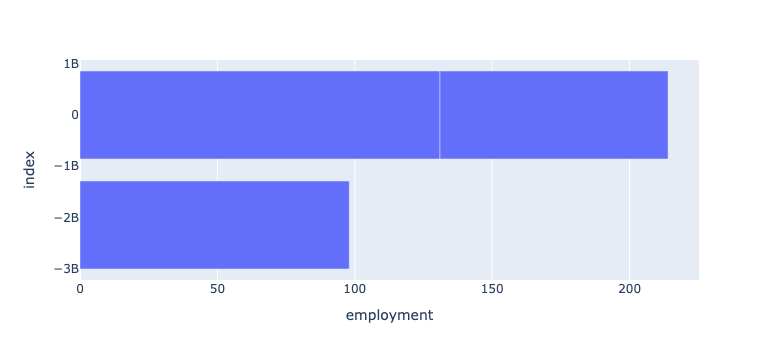

In [25]:
fig = px.bar(atus_df['employment'].value_counts(),
             x='employment')

fig.show()